In [1]:
import pandas as pd
  
# makes the passed rows header
data = pd.read_csv("laplace.csv", header =[0])

In [2]:
data

,x,y,u
0,0.00,0.0,0.00
1,0.01,0.0,0.01
2,0.02,0.0,0.02
3,0.03,0.0,0.03
4,0.04,0.0,0.04
...,...,...,...
10196,0.96,1.0,0.96
10197,0.97,1.0,0.97
10198,0.98,1.0,0.98
10199,0.99,1.0,0.99


In [3]:
import numpy as np
converted = np.array(data)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(converted[:,0:2], converted[:,2], test_size=0.33, random_state=42)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
# Keras :
from keras import backend as K
import tensorflow as tf
import keras 
from keras.layers import Input, Dense, add, Activation, Reshape , Conv1D, Flatten ,GlobalAveragePooling1D , Lambda, Dropout, concatenate
from keras.models import Model, model_from_json, model_from_yaml
from keras import optimizers 
from keras.callbacks import CSVLogger
from keras.losses import mse
from keras.utils.generic_utils import get_custom_objects

In [6]:

# optimizer (NAdam) parameters
lr = 0.05       # learning rate
beta_1=0.9       # beta 1
beta_2=0.999     # beta 2

In [7]:

class EarlyStoppingAtMinLoss(tf.keras.callbacks.Callback):
  """Stop training when the loss is at its min, i.e. the loss stops decreasing.

  Arguments:
      patience: Number of epochs to wait after min has been hit. After this
      number of no improvement, training stops.
  """

  def __init__(self, patience=20):
    super(EarlyStoppingAtMinLoss, self).__init__()

    self.patience = patience

    # best_weights to store the weights at which the minimum loss occurs.
    self.best_weights = None

  def on_train_begin(self, logs=None):
    # The number of epoch it has waited when loss is no longer minimum.
    self.wait = 0
    # The epoch the training stops at.
    self.stopped_epoch = 0
    # Initialize the best as infinity.
    self.best = np.Inf

  def on_epoch_end(self, epoch, logs=None):
    current = logs.get('loss')
    if np.less(current, self.best):
      self.best = current
      self.wait = 0
      # Record the best weights if current results is better (less).
      self.best_weights = self.model.get_weights()
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.stopped_epoch = epoch
        self.model.stop_training = True
        print('Restoring model weights from the end of the best epoch.')
        self.model.set_weights(self.best_weights)

  def on_train_end(self, logs=None):
    if self.stopped_epoch > 0:
      print('Epoch %05d: early stopping' % (self.stopped_epoch + 1))

In [11]:
class PDE(keras.layers.Layer):
    def __init__(self, units=32, input_dim=3):
        super(PDE, self).__init__()
        w_init = tf.random_normal_initializer()
        self.w = tf.Variable(
            initial_value=w_init(shape=(input_dim, units), dtype="float32"),
            trainable=True,
        )
        b_init = tf.zeros_initializer()
        self.b = tf.Variable(
            initial_value=b_init(shape=(units,), dtype="float32"), trainable=True
        )

    def call(self, inputs):
        with tf.GradientTape() as t:
            t.watch(inputs[0])
            t.watch(inputs[1])
            merged = keras.layers.Concatenate(axis=1)([inputs[0], inputs[1]])
            dense1 = keras.layers.Dense(10, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(merged)
            u = keras.layers.Dense(1, activation=keras.activations.relu, use_bias=True)(dense1)
        grad = t.gradient(u, {'x': inputs[0], 'y': inputs[1]})
        return -1*(grad['x']+grad['y']), u
        #return tf.matmul(inputs, self.w) + self.b

In [14]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
DE = PDE()
du,u=DE((x,y))
model666 = keras.models.Model(inputs=[x, y], outputs=[du,u])

In [18]:
model666.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_8 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
pde_2 (PDE)                     ((None, 1), (None, 1 128         input_7[0][0]                    
                                                                 input_8[0][0]                    
Total params: 128
Trainable params: 128
Non-trainable params: 0
__________________________________________________________________________________________________


In [16]:
model666.compile(optimizer=optimizers.Nadam(lr=0.05, beta_1=0.9, beta_2=0.999),
             loss=['mse','mse'],
             loss_weights=[0.5,0.5],
             metrics='mae'
             )

In [17]:
history666 = model666.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=300, batch_size=70, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/300


ValueError: in user code:

    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:805 train_function  *
        return step_function(self, iterator)
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:795 step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:1259 run
        return self._extended.call_for_each_replica(fn, args=args, kwargs=kwargs)
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:2730 call_for_each_replica
        return self._call_for_each_replica(fn, args, kwargs)
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/distribute/distribute_lib.py:3417 _call_for_each_replica
        return fn(*args, **kwargs)
    /home/samim/anaconda3/envs/tf

In [21]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
merged = keras.layers.Concatenate(axis=1)([x, y])
dense1 = keras.layers.Dense(10, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(merged)
u = keras.layers.Dense(1, activation=keras.activations.relu, use_bias=True)(dense1)
model = keras.models.Model(inputs=[x, y], outputs=u)

In [31]:
class DE(keras.layers.Layer):
    def __init__(self, input_dim=2):
        super(DE, self).__init__()
        self.grad = tf.Variable(initial_value=tf.zeros((input_dim,)), trainable=False)

    def call(self, inputs):
        with tf.GradientTape() as t:
            t.watch(inputs[0])
            t.watch(inputs[1])
            z = model([inputs[0],inputs[1]])
        self.grad = t.gradient(u, {'x': inputs[0], 'y': inputs[1]})
        return -1*(self.grad['x']+self.grad['y']), z

In [35]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
merged = keras.layers.Concatenate(axis=1)([x, y])
DDD = DE()
g, d = DDD(merged)
model333 = keras.models.Model(inputs=[x, y], outputs=[d,g])

AttributeError: in user code:

    <ipython-input-29-752c67cfdaba>:11 call  *
        self.grad = t.gradient(u, {'x': inputs[0], 'y': inputs[1]})
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/eager/backprop.py:1080 gradient  **
        flat_grad = imperative_grad.imperative_grad(
    /home/samim/anaconda3/envs/tf/lib/python3.8/site-packages/tensorflow/python/eager/imperative_grad.py:71 imperative_grad
        return pywrap_tfe.TFE_Py_TapeGradient(

    AttributeError: 'KerasTensor' object has no attribute '_id'


In [34]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
ml = model([x,y])
def grad2(I):
    with tf.GradientTape() as t:
        t.watch(I[0])
        t.watch(I[1])
        z = model(I)
    grad = t.gradient(z, {'x': I[0], 'y': I[1]})
    return -1*(grad['x']+grad['y'])
g = Lambda(grad2, name="grad2")((x,y))
d = keras.layers.Dense(2, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(ml)
model2 = keras.models.Model(inputs=[x, y], outputs=[d,g])

The following Variables were used a Lambda layer's call (grad2), but
are not present in its tracked objects:
  <tf.Variable 'dense_3/kernel:0' shape=(2, 10) dtype=float32>
  <tf.Variable 'dense_3/bias:0' shape=(10,) dtype=float32>
  <tf.Variable 'dense_4/kernel:0' shape=(10, 1) dtype=float32>
  <tf.Variable 'dense_4/bias:0' shape=(1,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.


In [35]:
opt = optimizers.Nadam(lr=0.05, beta_1=0.9, beta_2=0.999)

In [11]:
#model.compile(optimizer=opt,
#             loss='mse',
#             metrics='mae'
#             )
#history = model.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=150, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])  

In [37]:
model2.compile(optimizer=opt,
             loss=['mse','mse'],
             loss_weights=[0.5,0.5],
             metrics='mae'
             )
# fitting the data with model (learning process)
history2 = model2.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=300, batch_size=70, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/300
83/83 [==============================] - 6s 31ms/step - loss: 0.2075 - dense_5_loss: 0.0846 - grad2_loss: 0.3304 - dense_5_mae: 0.2520 - grad2_mae: 0.4950 - val_loss: 0.2056 - val_dense_5_loss: 0.0856 - val_grad2_loss: 0.3255 - val_dense_5_mae: 0.2548 - val_grad2_mae: 0.4905
Epoch 2/300
83/83 [==============================] - 1s 17ms/step - loss: 0.2144 - dense_5_loss: 0.0850 - grad2_loss: 0.3438 - dense_5_mae: 0.2532 - grad2_mae: 0.5088 - val_loss: 0.2056 - val_dense_5_loss: 0.0856 - val_grad2_loss: 0.3255 - val_dense_5_mae: 0.2549 - val_grad2_mae: 0.4905
Epoch 3/300
83/83 [==============================] - 2s 19ms/step - loss: 0.2088 - dense_5_loss: 0.0857 - grad2_loss: 0.3318 - dense_5_mae: 0.2541 - grad2_mae: 0.4963 - val_loss: 0.2058 - val_dense_5_loss: 0.0861 - val_grad2_loss: 0.3255 - val_dense_5_mae: 0.2553 - val_grad2_mae: 0.4905
Epoch 4/300
83/83 [==============================] - 2s 21ms/step - loss: 0.2166 - dense_5_loss: 0.0865 - grad2_loss: 0.3466 - dense_5_m

In [38]:
model2.evaluate([X_test[:,0],X_test[:,0]], y_test)

106/106 [==============================] - 1s 8ms/step - loss: 0.2080 - dense_5_loss: 0.0856 - grad2_loss: 0.3305 - dense_5_mae: 0.2523 - grad2_mae: 0.4953


[0.208029106259346,
 0.08555859327316284,
 0.330499529838562,
 0.25227585434913635,
 0.49532511830329895]

In [39]:
predicted_u = model2.predict([X_test[:,0],X_test[:,0]],batch_size=150)
predicted_u


[array([[0.5155016 , 0.51544976],
        [0.5155016 , 0.51544976],
        [0.5155016 , 0.51544976],
        ...,
        [0.5155016 , 0.51544976],
        [0.5155016 , 0.51544976],
        [0.5155016 , 0.51544976]], dtype=float32),
 array([[-0.],
        [-0.],
        [-0.],
        ...,
        [-0.],
        [-0.],
        [-0.]], dtype=float32)]

In [40]:
print('mean of prediction : %.8f' % (np.mean(predicted_u[0])))
print('norm of the mean of the commited error : %.8f' % (np.linalg.norm(np.mean(predicted_u[0]) - np.mean(y_test))))


mean of prediction : 0.51547563
norm of the mean of the commited error : 0.02015042


In [41]:
err =[]
for i in range(len(predicted_u[0])):
    err.append(predicted_u[0][i]-y_test[i])
err = np.array(err)
print('mean of L2 commited error: %.8f'%(np.linalg.norm(err)))

mean of L2 commited error: 24.00315475


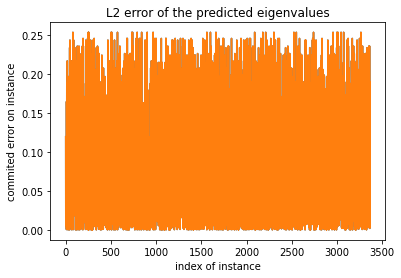

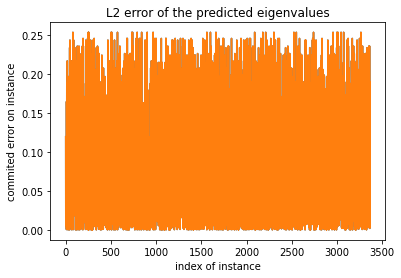

Percentage of the commited error between 0,5e-6 is: 0.00000000
Percentage of the commited error between 5e-6,5e-5 is: 1.84140184
Percentage of the commited error between 5e-5,5e-4 is: 2.13840214
Percentage of the commited error between 5e-4,5e-3 is: 9.86040986
Percentage of the commited error between 5e-3,5e-2 is: 30.88803089
Percentage of the commited error between 5e-2,5e-1 is: 55.27175527
Percentage of the commited error between 0,5e-6 is: 0.00000000
Percentage of the commited error between 5e-6,5e-5 is: 1.84140184
Percentage of the commited error between 5e-5,5e-4 is: 2.13840214
Percentage of the commited error between 5e-4,5e-3 is: 9.86040986
Percentage of the commited error between 5e-3,5e-2 is: 30.88803089
Percentage of the commited error between 5e-2,5e-1 is: 55.27175527


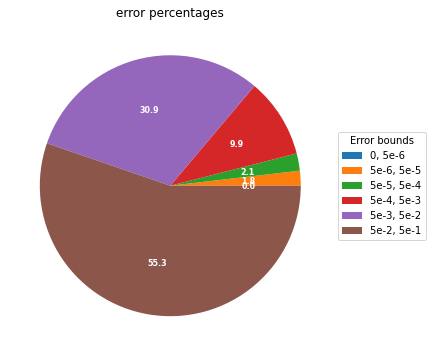

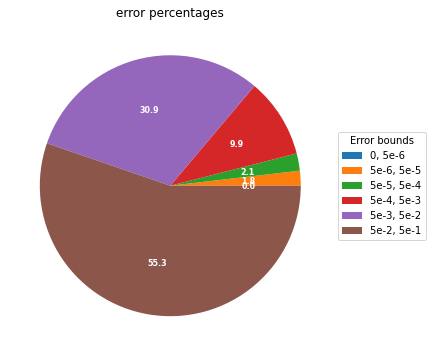

In [20]:
L2_Errors = []
for i in range(len(predicted_u[0])):
    L2_Errors.append((y_test[i] - predicted_u[0][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6", 
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

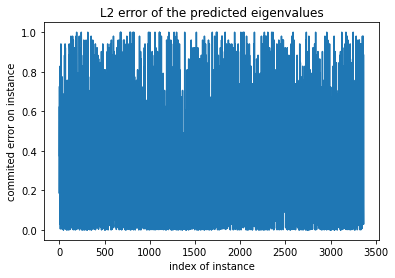

Percentage of the commited error between 0,5e-6 is: 0.83160083
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 1.98990199
Percentage of the commited error between 5e-4,5e-3 is: 6.08850609
Percentage of the commited error between 5e-3,5e-2 is: 13.98871399
Percentage of the commited error between 5e-2,5e-1 is: 48.52984853


<ipython-input-42-53880c1db7a4>:61: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),


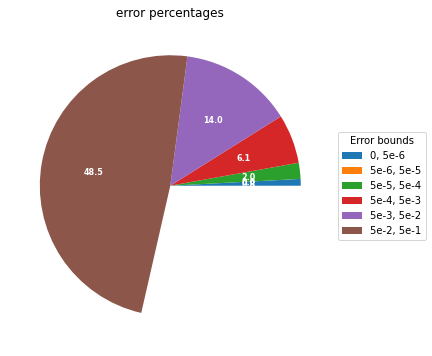

In [42]:
L2_Errors = []
for i in range(len(predicted_u[1])):
    L2_Errors.append((y_test[i] - predicted_u[1][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6", 
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

In [43]:
print(history2.history.keys())

dict_keys(['loss', 'dense_5_loss', 'grad2_loss', 'dense_5_mae', 'grad2_mae', 'val_loss', 'val_dense_5_loss', 'val_grad2_loss', 'val_dense_5_mae', 'val_grad2_mae'])


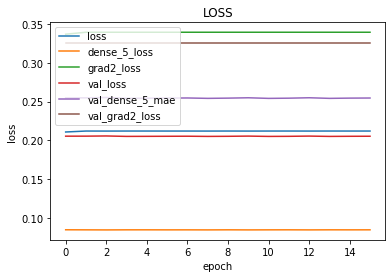

In [46]:
# summarize history for accuracy
plt.plot(history2.history['loss'])
plt.plot(history2.history['dense_5_loss'])
plt.plot(history2.history['grad2_loss'])
plt.plot(history2.history['val_loss'])
plt.plot(history2.history['val_dense_5_mae'])
plt.plot(history2.history['val_grad2_loss'])
plt.title('LOSS')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'dense_5_loss', 'grad2_loss','val_loss', 'val_dense_5_mae', 'val_grad2_loss'], loc='upper left')
#plt.show()
plt.savefig('plot1.pdf', bbox_inches='tight')

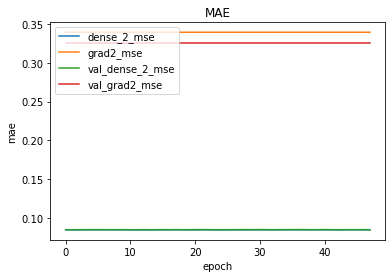

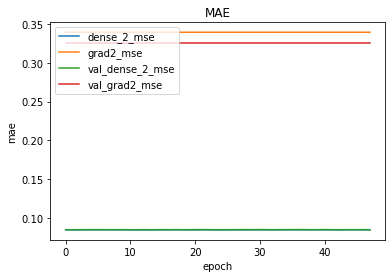

In [24]:
plt.plot(history2.history['dense_2_mse'])
plt.plot(history2.history['grad2_mse'])
plt.plot(history2.history['val_dense_2_mse'])
plt.plot(history2.history['val_grad2_mse'])
plt.title('MAE')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['dense_2_mse', 'grad2_mse', 'val_dense_2_mse', 'val_grad2_mse'], loc='upper left')
#plt.show()
plt.savefig('plot2.pdf', bbox_inches='tight')